In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib as plt
import numpy as np
from tensorflow.keras import layers, Model

/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:93: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


/usr/local/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# Part 1: Data Preparation
## 1. Dataset Loading
### Split into training and testing subsets

In [2]:
(ds_train,_),ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:90%]','train[90%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
    )

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9


...

Corrupt JPEG data: 252 extraneous bytes before marker 0xd9


Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.U0CAFZ_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


## 2. Preprocessing:
### o Resize all images to 64×64 pixels
### o Normalize pixel values to the [-1, 1] range
### o Cast labels to integer format
### o Create training batches with labels

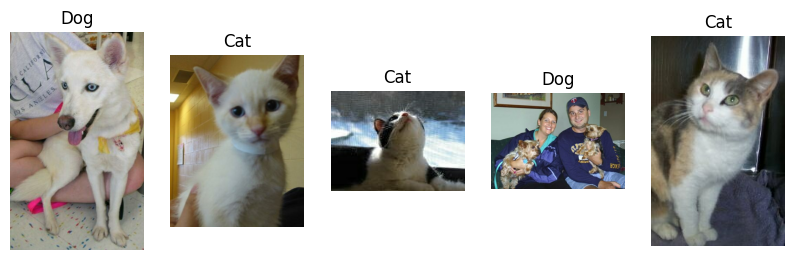

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
for i, (image, label) in enumerate(ds_train.take(5)): # Display 5 images
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title('Dog' if label == 1 else 'Cat')
    plt.axis('off')
plt.show()

In [4]:
# Define target dimension
TARGET_HEIGHT = 64
TARGET_WIDTH = 64

def preprocess_image(image, label):
    # Resize all images to 64x64 pixels
    image = tf.image.resize(image, (TARGET_HEIGHT, TARGET_WIDTH))
    # Normalize pixel values to the [-1, 1] range
    image = tf.keras.layers.Rescaling(scale=1./127.5, offset=-1)(image)
    # Cast labels to integer format (tfds.load with as_supervised usually does this, but good to be explicit)
    label = tf.cast(label, tf.int32)
    return image, label

In [5]:
BATCH_SIZE = 32

ds_train_processed = ds_train.map(preprocess_image)
ds_train_batched = ds_train_processed.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

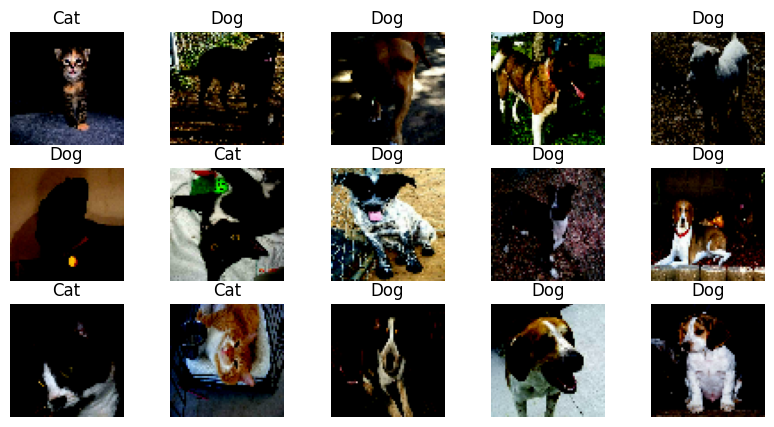

In [6]:
plt.figure(figsize=(10, 5))
for i, (image, label) in enumerate(ds_train_batched.take(15)): # Display 15 images
    plt.subplot(3, 5, i + 1)
    plt.imshow((image[0])) # Denormalize from [-1, 1] to [0, 1] for display
    # plt.imshow((image[0] + 1) / 2) # Denormalize from [-1, 1] to [0, 1] for display
    plt.title('Dog' if label[0] == 1 else 'Cat') # Use the label of the first image
    plt.axis('off')
plt.show()

# Part 2: Conditional GAN Architecture
## 1. Generator
### o Accepts both noise vector and class label as input
### o Uses label embedding and concatenates it with noise
### o Builds up to a 64×64×3 image using Conv2DTranspose layers

In [7]:
# Redefine strategy for self-containment in this cell
try:
    # Detect TPU hardware
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print('Running on TPU ', tpu.master())
except ValueError:
    print('Could not find TPU, running on GPU or CPU')
    tpu = None

if tpu:
    try:
        tf.config.experimental_connect_to_cluster(tpu)
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        print(f'TPUStrategy created with {strategy.num_replicas_in_sync} replicas in sync')
    except Exception as e:
        print(f'Failed to connect to TPU: {e}')
        strategy = tf.distribute.get_strategy()
        print(f'Default strategy created: {strategy.num_replicas_in_sync} replicas in sync')
else:
    # Default to CPU/GPU strategy if TPU is not available
    strategy = tf.distribute.get_strategy()
    print(f'Default strategy created: {strategy.num_replicas_in_sync} replicas in sync')


Could not find TPU, running on GPU or CPU
Default strategy created: 1 replicas in sync


In [8]:
NUM_CLASSES = 2
def build_cgan_generator(latent_dim=100, num_classes=NUM_CLASSES):
    # 1. Label Input & Embedding
    label_input = layers.Input(shape=(1,), name="label_input")
    # Embedding maps label to a vector, then flatten to match noise shape
    label_embedding = layers.Embedding(num_classes, latent_dim)(label_input)
    label_embedding = layers.Flatten()(label_embedding)

    # 2. Noise Input
    noise_input = layers.Input(shape=(latent_dim,), name="noise_input")

    # 3. Concatenate Label + Noise
    merged = layers.Concatenate()([noise_input, label_embedding])

    # 4. Foundation for 4x4 image
    x = layers.Dense(4 * 4 * 512)(merged)
    x = layers.Reshape((4, 4, 512))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 5. Upsampling to 64x64x3
    # 4x4 -> 8x8
    x = layers.Conv2DTranspose(256, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 8x8 -> 16x16
    x = layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 16x16 -> 32x32
    x = layers.Conv2DTranspose(64, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 32x32 -> 64x64
    x = layers.Conv2DTranspose(3, kernel_size=4, strides=2, padding="same", activation="tanh")(x)

    return Model([noise_input, label_input], x, name="cGAN_Generator")

with strategy.scope():
    generator = build_cgan_generator()
generator.summary()


Model: "cGAN_Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 100)    │        200 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_input         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 100)       │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 200)       │          0 │ noise_input[0][0… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8192)      │  1,646,592 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 4, 4, 512) │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 4, 4, 512) │      2,048 │ reshape[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 4, 4, 512) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 8, 8, 256) │  2,097,408 │ re_lu[0][0]       │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 16, 16,    │    524,416 │ re_lu_1[0][0]     │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_2  │ (None, 32, 32,    │    131,136 │ re_lu_2[0][0]     │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,406,667 (16.81 MB)

 Trainable params: 4,404,747 (16.80 MB)

 Non-trainable params: 1,920 (7.50 KB)

## 2. Discriminator
### o Accepts both real/fake image and class label
### o Embeds label and concatenates it with image
### o Uses Conv2D layers to classify input as real/fake

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_cgan_discriminator(img_shape=(64, 64, 3), num_classes=NUM_CLASSES):
    # 1. Label Input & Embedding
    label_input = layers.Input(shape=(1,), name="label_input")

    # Embed label and expand to match image spatial dimensions (64x64)
    # We create a 1D vector, then use Dense to expand it to 64*64*1
    le = layers.Embedding(num_classes, 50)(label_input)
    le = layers.Dense(img_shape[0] * img_shape[1])(le)
    le = layers.Reshape((img_shape[0], img_shape[1], 1))(le)

    # 2. Image Input
    img_input = layers.Input(shape=img_shape, name="image_input")

    # 3. Concatenate Image + Label (adds the label as a 4th channel)
    merged = layers.Concatenate()([img_input, le])

    # 4. Downsampling with Conv2D layers
    # 64x64 -> 32x32
    x = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(merged)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # 32x32 -> 16x16
    x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # 16x16 -> 8x8
    x = layers.Conv2D(256, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    # 5. Output Layer
    x = layers.Flatten()(x)
    x = layers.Dropout(0.4)(x)
    output = layers.Dense(1, activation="sigmoid")(x) # Real vs Fake

    return Model([img_input, label_input], output, name="cGAN_Discriminator")

with strategy.scope():    
    discriminator = build_cgan_discriminator()
discriminator.summary()


/usr/local/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "cGAN_Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │        100 │ label_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 4096)   │    208,896 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 64, 64, 1) │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64, 4) │          0 │ image_input[0][0… │
│ (Concatenate)       │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      4,160 │ concatenate_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │    131,200 │ leaky_re_lu[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │        512 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 256) │    524,544 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 256) │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 8, 8, 256) │          0 │ batch_normalizat… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16384)     │          0 │ leaky_re_lu_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16384)     │          0 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │     16,385 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 886,821 (3.38 MB)

 Trainable params: 886,053 (3.38 MB)

 Non-trainable params: 768 (3.00 KB)

## Part 3: Loss Functions and Optimizer
### • Generator Loss: Binary cross-entropy encouraging discriminator to classify generated images as real
### • Discriminator Loss: Binary cross-entropy distinguishing real vs fake images
### • Optimizers: Adam optimizer for both networks


In [10]:
# Standard Adam optimizer settings for GANs
GAN_BETA1 = 0.5
LEARNING_RATE = 0.0002

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=GAN_BETA1)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, beta_1=GAN_BETA1)

# Use 'from_logits=False' if the discriminator output uses a sigmoid activation
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    #Loss on real images (should be all 1s)
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)

    #Loss on fake image(should be all 0s)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)

    #Total loss is the sum
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    #Loss on fake images (should be all 1s)
    return cross_entropy(tf.ones_like(fake_output), fake_output)

## Part 4: Training the Model
### • Train the generator and discriminator alternately
### • Use @tf.function for optimized performance
### • Train for a minimum of 10 epochs
### • Print training progress per epoch


In [11]:
import tensorflow as tf

@tf.function
def train_step(images, labels, generator, discriminator, gen_optimizer, disc_optimizer, latent_dim):
    # Generate random noise for the batch
    batch_size = tf.shape(images)[0]
    noise = tf.random.normal([batch_size, latent_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # 1. Generate fake images using noise and the real labels
        generated_images = generator([noise, labels], training=True)

        # 2. Get discriminator output for real images + labels
        real_output = discriminator([images, labels], training=True)
        # 3. Get discriminator output for fake images + labels
        fake_output = discriminator([generated_images, labels], training=True)

        # 4. Calculate Losses
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # 5. Calculate and apply gradients for Discriminator
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    disc_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    # 6. Calculate and apply gradients for Generator
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gen_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))

    return gen_loss, disc_loss


In [12]:
import time

def train(dataset, epochs, generator, discriminator, generator_optimizer, discriminator_optimizer,latent_dim):
    for epoch in range(epochs):
        start = time.time()

        # Accumulators for avg loss reporting
        gen_loss_avg = tf.keras.metrics.Mean()
        disc_loss_avg = tf.keras.metrics.Mean()

        for images_batch, label_batch in dataset:
            gen_loss, disc_loss = train_step(images_batch,
                                             label_batch,
                                             generator,
                                             discriminator,
                                             generator_optimizer,
                                             discriminator_optimizer,
                                             latent_dim=100)
            gen_loss_avg(gen_loss)
            disc_loss_avg(disc_loss)

        # Print progress per epoch
        print("---------------------------------------------------")
        print(f"Epoch {epoch+1}/{epochs} | "
          f"Gen Loss: {gen_loss_avg.result():.4f} | "
          f"Disc Loss: {disc_loss_avg.result():.4f} | "
          f"Time: {time.time()-start:.2f}s")
        print("---------------------------------------------------")
        
#Execute Training
LATENT_DIM = 100
EPOCHS = 50
# train(ds_train_batched, EPOCHS, generator, discriminator, generator_optimizer, discriminator_optimizer)

# dataset = Your preprocessed tf.data.Dataset yielding (64,64,3) images and labels
train(ds_train_batched, EPOCHS, generator, discriminator, generator_optimizer, discriminator_optimizer, LATENT_DIM)


---------------------------------------------------
Epoch 1/50 | Gen Loss: 1.9930 | Disc Loss: 0.9534 | Time: 76.71s
---------------------------------------------------


---------------------------------------------------
Epoch 2/50 | Gen Loss: 2.1003 | Disc Loss: 0.8011 | Time: 70.92s
---------------------------------------------------


---------------------------------------------------
Epoch 3/50 | Gen Loss: 2.1988 | Disc Loss: 0.8343 | Time: 70.87s
---------------------------------------------------


---------------------------------------------------
Epoch 4/50 | Gen Loss: 2.3899 | Disc Loss: 0.7388 | Time: 70.17s
---------------------------------------------------


---------------------------------------------------
Epoch 5/50 | Gen Loss: 2.6108 | Disc Loss: 0.6850 | Time: 70.79s
---------------------------------------------------


...

---------------------------------------------------
Epoch 46/50 | Gen Loss: 3.7815 | Disc Loss: 0.4624 | Time: 70.24s
---------------------------------------------------


---------------------------------------------------
Epoch 47/50 | Gen Loss: 3.9923 | Disc Loss: 0.5003 | Time: 70.61s
---------------------------------------------------


---------------------------------------------------
Epoch 48/50 | Gen Loss: 3.8484 | Disc Loss: 0.4561 | Time: 70.82s
---------------------------------------------------


---------------------------------------------------
Epoch 49/50 | Gen Loss: 4.0733 | Disc Loss: 0.4459 | Time: 70.54s
---------------------------------------------------


---------------------------------------------------
Epoch 50/50 | Gen Loss: 4.0643 | Disc Loss: 0.4254 | Time: 70.95s
---------------------------------------------------


## Part 5: Evaluation and Visualization
### • Generate images conditioned on randomly chosen labels
### • Display generated images with corresponding label titles
### • Ensure images are normalized back to [0, 1] for display


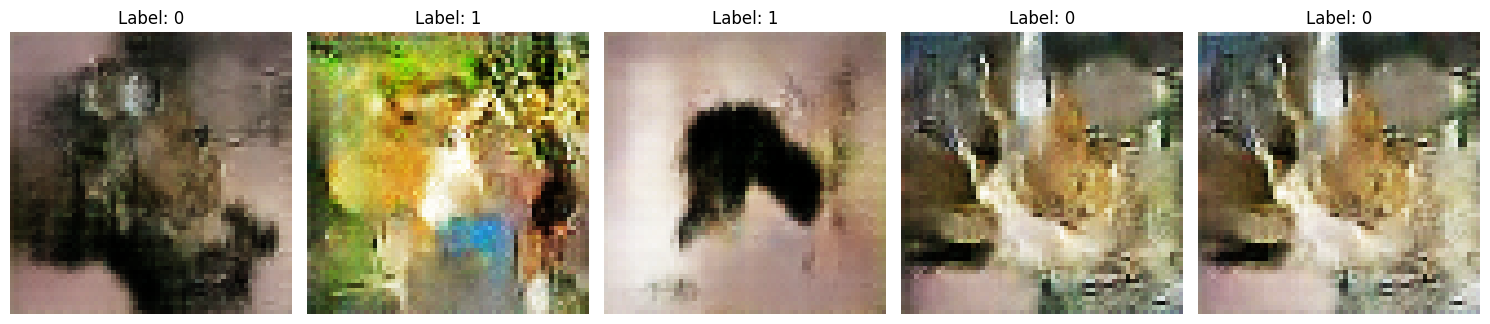

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_generated_images(generator, num_classes, latent_dim=100, num_examples=5):
    # 1. Prepare random noise and random labels
    noise = tf.random.normal([num_examples, latent_dim])
    # Pick random class labels
    random_labels = tf.random.uniform([num_examples], minval=0, maxval=num_classes, dtype=tf.int32)

    # 2. Generate images (inference mode: training=False)
    generated_images = generator([noise, random_labels], training=False)

    # 3. Normalize back to [0, 1] for visualization
    # Formula: (img + 1) / 2
    normalized_images = (generated_images + 1.0) / 2.0

    # 4. Display the images
    plt.figure(figsize=(15, 5))
    for i in range(num_examples):
        plt.subplot(1, num_examples, i + 1)
        # Convert to numpy and ensure the range is clipped to [0, 1] just in case
        img_to_show = np.clip(normalized_images[i], 0, 1)

        plt.imshow(img_to_show)
        plt.title(f"Label: {random_labels[i].numpy()}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage after training:
visualize_generated_images(generator, num_classes=NUM_CLASSES )
